# Classifying Penguins with Keras

In [63]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [64]:
! pip install palmerpenguins
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [65]:
penguins = penguins.dropna()
penguins.shape

(333, 8)

In [66]:
#shuffle the data
penguins = penguins.sample(frac = 1, random_state=42).reset_index(drop=True)
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Dream,39.5,16.7,178.0,3250.0,female,2007
1,Chinstrap,Dream,50.9,17.9,196.0,3675.0,female,2009
2,Adelie,Torgersen,42.1,19.1,195.0,4000.0,male,2008
3,Gentoo,Biscoe,46.6,14.2,210.0,4850.0,female,2008
4,Adelie,Biscoe,41.1,18.2,192.0,4050.0,male,2008


In [67]:
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]
penguins_x

,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm,female,male
0,3250.0,39.5,16.7,178.0,True,False
1,3675.0,50.9,17.9,196.0,True,False
2,4000.0,42.1,19.1,195.0,False,True
3,4850.0,46.6,14.2,210.0,True,False
4,4050.0,41.1,18.2,192.0,False,True
...,...,...,...,...,...,...
328,4750.0,49.6,15.0,216.0,False,True
329,3900.0,37.2,19.4,184.0,False,True
330,3200.0,39.7,17.7,193.0,True,False
331,3950.0,45.2,17.8,198.0,True,False


In [68]:
x = penguins_x.values
min_max_scaler = StandardScaler()
scaled_penguins_x = pd.DataFrame(min_max_scaler.fit_transform(x), columns=penguins_x.columns)
scaled_penguins_x

,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm,female,male
0,-1.190361,-0.822788,-0.236419,-1.641118,1.009050,-1.009050
1,-0.661758,1.264952,0.373872,-0.354918,1.009050,-1.009050
2,-0.257532,-0.346637,0.984162,-0.426373,-0.991031,0.991031
3,0.799674,0.477471,-1.507858,0.645461,1.009050,-1.009050
4,-0.195343,-0.529772,0.526444,-0.640740,-0.991031,0.991031
...,...,...,...,...,...,...
328,0.675297,1.026876,-1.100997,1.074194,-0.991031,0.991031
329,-0.381909,-1.243998,1.136735,-1.212385,-0.991031,0.991031
330,-1.252549,-0.786161,0.272157,-0.569284,1.009050,-1.009050
331,-0.319720,0.221082,0.323014,-0.212006,1.009050,-1.009050


In [69]:
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

0         Adelie
1      Chinstrap
2         Adelie
3         Gentoo
4         Adelie
         ...    
328       Gentoo
329       Adelie
330       Adelie
331    Chinstrap
332       Adelie
Name: species, Length: 333, dtype: object


array([0, 1, 0, 2, 0, 1, 1, 2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 2, 0, 1, 0, 0,
       1, 2, 0, 0, 2, 1, 2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 0, 0, 0, 0, 2, 2,
       0, 0, 1, 0, 0, 1, 0, 2, 2, 0, 0, 2, 0, 0, 2, 2, 1, 1, 1, 0, 0, 1,
       0, 2, 0, 1, 0, 0, 2, 1, 2, 2, 0, 0, 0, 2, 0, 0, 2, 0, 1, 2, 0, 1,
       2, 2, 2, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 1, 0, 2, 0, 2, 2, 0, 2,
       0, 1, 0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 1, 0, 0, 1, 0, 0, 0, 2, 0, 0,
       2, 0, 0, 0, 2, 0, 1, 0, 0, 2, 0, 1, 2, 1, 2, 1, 2, 2, 2, 2, 0, 0,
       2, 2, 2, 0, 2, 2, 0, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0, 2, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 2, 1, 0, 2, 2, 0, 1, 0, 1, 0, 2, 0, 2, 0, 0, 0,
       2, 0, 2, 0, 1, 0, 0, 2, 2, 2, 0, 0, 0, 2, 2, 0, 0, 1, 0, 2, 0, 1,
       1, 1, 0, 2, 1, 2, 2, 0, 2, 0, 0, 2, 0, 2, 0, 2, 1, 0, 1, 2, 1, 0,
       2, 2, 2, 0, 0, 0, 2, 2, 2, 1, 2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 1,
       1, 2, 1, 2, 2, 2, 1, 2, 1, 1, 1, 2, 2, 0, 2, 2, 2, 0, 0, 0, 0, 0,
       2, 0, 2, 0, 0, 2, 2, 0, 0, 1, 2, 1, 0, 1, 2,

In [70]:
#construct the model
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
x = layers.Dense(3, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [71]:
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119 (476.00 B)

 Trainable params: 119 (476.00 B)

 Non-trainable params: 0 (0.00 B)

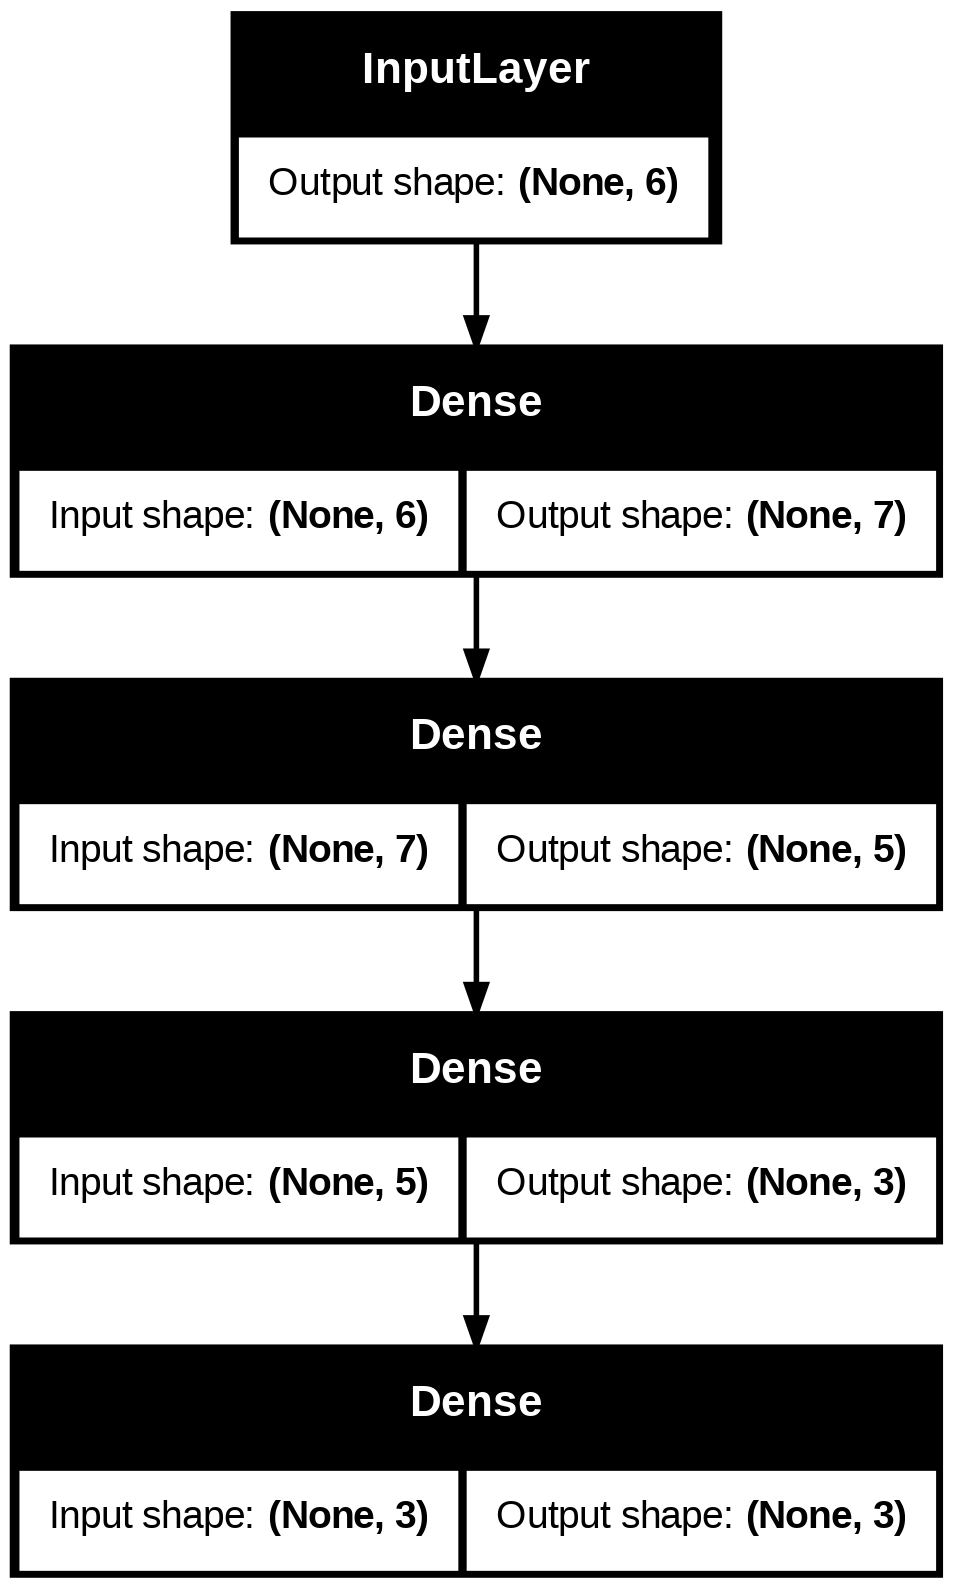

In [72]:
keras.utils.plot_model(model, show_shapes = True)

In [73]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)

history = model.fit(scaled_penguins_x, penguins_y, batch_size = 64, epochs=100, validation_split=0.1)

scores = model.evaluate(scaled_penguins_x, penguins_y, verbose=2)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3906 - loss: 1.0867

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.4415 - loss: 1.0240 - val_accuracy: 0.4118 - val_loss: 0.9752
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4548 - loss: 0.9950 - val_accuracy: 0.4706 - val_loss: 0.9512
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4983 - loss: 0.9768 - val_accuracy: 0.4706 - val_loss: 0.9319
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5284 - loss: 0.9617 - val_accuracy: 0.5294 - val_loss: 0.9160
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.5786 - loss: 0.9487 - val_accuracy: 0.5588 - val_loss: 0.9014
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6054 - loss: 0.9366 - val_accuracy: 0.6471 - val_loss: 0.8884
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6455 - loss: 0.9255 - val_accuracy: 0.6765 - val_loss: 0.8756
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6622 - loss: 0.9145 - val_accuracy: 0.7353 - val_loss: 0.8632
Epo

In [78]:
model_logit_false = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model_scaled")

model_logit_false.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)

history_logit_false = model_logit_false.fit(scaled_penguins_x, penguins_y, batch_size = 64, epochs = 100, validation_split = 0.1)

scores = model_logit_false.evaluate(scaled_penguins_x, penguins_y, verbose = 2)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.7960 - loss: 0.4677 - val_accuracy: 0.7941 - val_loss: 0.4404
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7960 - loss: 0.4668 - val_accuracy: 0.7941 - val_loss: 0.4399
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7960 - loss: 0.4663 - val_accuracy: 0.7941 - val_loss: 0.4394
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7960 - loss: 0.4657 - val_accuracy: 0.7941 - val_loss: 0.4389
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7960 - loss: 0.4652 - val_accuracy: 0.7941 - val_loss: 0.4385
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7960 - loss: 0.4647 - val_accuracy: 0.7941 - val_loss: 0.4381
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7960 - loss: 0.4643 - val_accuracy: 0.7941 - val_loss: 0.4378
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7960 - loss: 0.4638 - val_accuracy: 0.7941 - val_loss:

In [75]:
model_logit_true.predict(scaled_penguins_x)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


array([[6.22683883e-01, 2.83095062e-01, 9.42210406e-02],
       [6.22683883e-01, 2.83095062e-01, 9.42210406e-02],
       [6.22683883e-01, 2.83095062e-01, 9.42210406e-02],
       [6.08284324e-07, 6.73631803e-07, 9.99998629e-01],
       [6.22683883e-01, 2.83095062e-01, 9.42210406e-02],
       [6.22683883e-01, 2.83095062e-01, 9.42210406e-02],
       [6.22683883e-01, 2.83095062e-01, 9.42210406e-02],
       [7.70188478e-07, 1.01545118e-06, 9.99998152e-01],
       [1.29633582e-09, 2.56321031e-09, 9.99999940e-01],
       [1.92789466e-05, 1.69099403e-05, 9.99963701e-01],
       [6.22683883e-01, 2.83095062e-01, 9.42210406e-02],
       [6.22683883e-01, 2.83095062e-01, 9.42210406e-02],
       [6.22683883e-01, 2.83095062e-01, 9.42210406e-02],
       [6.22683883e-01, 2.83095062e-01, 9.42210406e-02],
       [6.22683883e-01, 2.83095062e-01, 9.42210406e-02],
       [6.22683883e-01, 2.83095062e-01, 9.42210406e-02],
       [6.22683883e-01, 2.83095062e-01, 9.42210406e-02],
       [5.32648926e-07, 5.63053

In [76]:
penguins['species']

,species
0,Adelie
1,Chinstrap
2,Adelie
3,Gentoo
4,Adelie
...,...
328,Gentoo
329,Adelie
330,Adelie
331,Chinstrap


In [77]:
penguins_y

array([0, 1, 0, 2, 0, 1, 1, 2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 2, 0, 1, 0, 0,
       1, 2, 0, 0, 2, 1, 2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 0, 0, 0, 0, 2, 2,
       0, 0, 1, 0, 0, 1, 0, 2, 2, 0, 0, 2, 0, 0, 2, 2, 1, 1, 1, 0, 0, 1,
       0, 2, 0, 1, 0, 0, 2, 1, 2, 2, 0, 0, 0, 2, 0, 0, 2, 0, 1, 2, 0, 1,
       2, 2, 2, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 1, 0, 2, 0, 2, 2, 0, 2,
       0, 1, 0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 1, 0, 0, 1, 0, 0, 0, 2, 0, 0,
       2, 0, 0, 0, 2, 0, 1, 0, 0, 2, 0, 1, 2, 1, 2, 1, 2, 2, 2, 2, 0, 0,
       2, 2, 2, 0, 2, 2, 0, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0, 2, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 2, 1, 0, 2, 2, 0, 1, 0, 1, 0, 2, 0, 2, 0, 0, 0,
       2, 0, 2, 0, 1, 0, 0, 2, 2, 2, 0, 0, 0, 2, 2, 0, 0, 1, 0, 2, 0, 1,
       1, 1, 0, 2, 1, 2, 2, 0, 2, 0, 0, 2, 0, 2, 0, 2, 1, 0, 1, 2, 1, 0,
       2, 2, 2, 0, 0, 0, 2, 2, 2, 1, 2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 1,
       1, 2, 1, 2, 2, 2, 1, 2, 1, 1, 1, 2, 2, 0, 2, 2, 2, 0, 0, 0, 0, 0,
       2, 0, 2, 0, 0, 2, 2, 0, 0, 1, 2, 1, 0, 1, 2,